In [1]:
# ==========================================
# Project 8 - Movie Review Sentiment Analysis
# Step 2 - Import Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb

print("TensorFlow Version:", tf.__version__)
print("Libraries Imported Successfully!")

TensorFlow Version: 2.20.0
Libraries Imported Successfully!


In [2]:
# ==========================================
# Load IMDB Dataset
# ==========================================

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=10000
)

print("Dataset Loaded Successfully!")

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully!
Training Samples: 25000
Testing Samples: 25000


In [3]:
print("First Review:")
print(X_train[0])

print("\nFirst Label:")
print(y_train[0])

First Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First Label:
1


In [4]:
print("Unique Labels:", np.unique(y_train))

Unique Labels: [0 1]


In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
# ==========================================
# Step 5 - Padding Reviews
# ==========================================

max_length = 200

X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Padding Completed!")
print("Training Shape:", X_train_padded.shape)
print("Testing Shape:", X_test_padded.shape)

Padding Completed!
Training Shape: (25000, 200)
Testing Shape: (25000, 200)


In [7]:
print(X_train_padded[0])

[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5  144   30 5535   18   51   36   28  224   92   25  104
    4 

In [8]:
# Check how many zero values are present
zero_count = np.sum(X_train_padded[0] == 0)

print("Number of Padding Zeros:", zero_count)

Number of Padding Zeros: 0


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [10]:
# ==========================================
# Build LSTM Sentiment Analysis Model
# ==========================================

vocab_size = 10000
embedding_dim = 128
lstm_units = 64

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=200
    ),

    LSTM(lstm_units),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ==========================================
# Compile LSTM Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [12]:
# ==========================================
# Train LSTM Model
# ==========================================

history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 265ms/step - accuracy: 0.5254 - loss: 0.6894 - val_accuracy: 0.6274 - val_loss: 0.6465
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.5845 - loss: 0.6591 - val_accuracy: 0.5936 - val_loss: 0.6289
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 267ms/step - accuracy: 0.6071 - loss: 0.6568 - val_accuracy: 0.5356 - val_loss: 0.6839
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 270ms/step - accuracy: 0.6842 - loss: 0.5760 - val_accuracy: 0.6612 - val_loss: 0.5478
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 269ms/step - accuracy: 0.8103 - loss: 0.4397 - val_accuracy: 0.5208 - val_loss: 0.9358


In [13]:
# ==========================================
# Evaluate LSTM Model
# ==========================================

test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5143 - loss: 0.9493
Test Loss: 0.9492884874343872
Test Accuracy: 0.5142800211906433


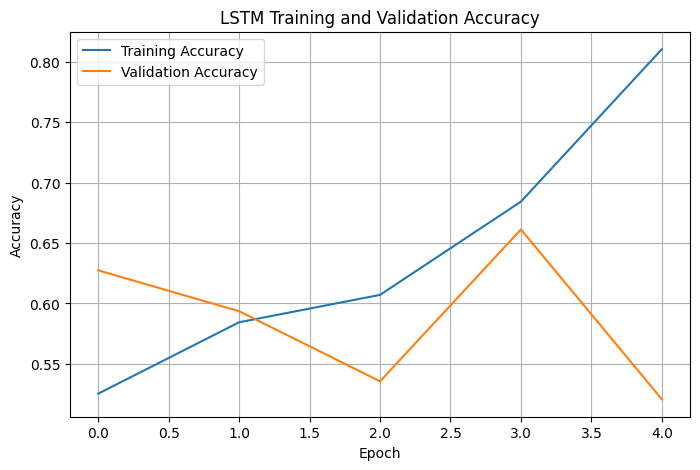

In [15]:
# ==========================================
# LSTM Training Accuracy
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

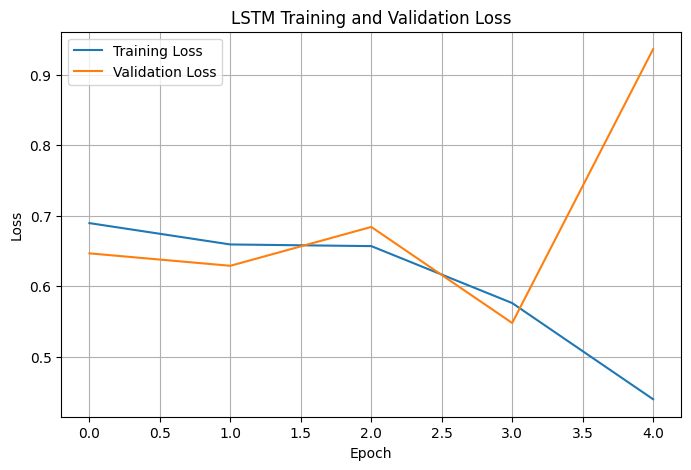

In [16]:
# ==========================================
# LSTM Training Loss
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [17]:
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 51.43%


In [18]:
# ==========================================
# Get IMDB Word Index
# ==========================================

word_index = imdb.get_word_index()

print("Vocabulary Size:", len(word_index))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Vocabulary Size: 88584


In [19]:
# ==========================================
# Convert Text Review to Model Input
# ==========================================

def encode_review(review):

    words = review.lower().split()

    encoded = []

    for word in words:

        if word in word_index:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)

    encoded = [1] + encoded

    padded = pad_sequences(
        [encoded],
        maxlen=200,
        padding='post',
        truncating='post'
    )

    return padded

In [20]:
# ==========================================
# Predict Sentiment
# ==========================================

def predict_sentiment(review):

    encoded_review = encode_review(review)

    probability = model.predict(encoded_review, verbose=0)[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Probability:", round(float(probability), 4))

In [21]:
predict_sentiment(
    "This movie was amazing, entertaining and absolutely wonderful"
)

Review: This movie was amazing, entertaining and absolutely wonderful
Prediction: Positive
Probability: 0.6263


In [22]:
predict_sentiment(
    "This movie was boring, terrible and very disappointing"
)

Review: This movie was boring, terrible and very disappointing
Prediction: Negative
Probability: 0.4347


In [23]:
# ==========================================
# Test Multiple Movie Reviews
# ==========================================

reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "The movie was boring and a complete waste of time.",
    "The acting was excellent and the story was very interesting.",
    "I hated this movie. It was terrible and disappointing.",
    "The movie was okay but nothing special."
]

for review in reviews:
    predict_sentiment(review)
    print("-" * 60)


Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive
Probability: 0.625
------------------------------------------------------------
Review: The movie was boring and a complete waste of time.
Prediction: Negative
Probability: 0.4332
------------------------------------------------------------
Review: The acting was excellent and the story was very interesting.
Prediction: Positive
Probability: 0.6256
------------------------------------------------------------
Review: I hated this movie. It was terrible and disappointing.
Prediction: Negative
Probability: 0.4335
------------------------------------------------------------
Review: The movie was okay but nothing special.
Prediction: Negative
Probability: 0.4372
------------------------------------------------------------


In [24]:
# ==========================================
# Find Misclassified Reviews
# ==========================================

predictions = model.predict(
    X_test_padded,
    verbose=0
).flatten()

predicted_labels = (predictions >= 0.5).astype(int)

wrong_indices = np.where(predicted_labels != y_test)[0]

print("Total Test Reviews:", len(y_test))
print("Correct Predictions:",
      np.sum(predicted_labels == y_test))
print("Wrong Predictions:",
      len(wrong_indices))

Total Test Reviews: 25000
Correct Predictions: 12857
Wrong Predictions: 12143


In [26]:
# ==========================================
# Show Misclassified Reviews
# ==========================================

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

for index in wrong_indices[:5]:

    review_numbers = X_test[index]

    words = []

    for number in review_numbers:

        if number >= 3:
            word = reverse_word_index.get(number, "?")
            words.append(word)

    review_text = " ".join(words)

    actual = "Positive" if y_test[index] == 1 else "Negative"
    predicted = "Positive" if predicted_labels[index] == 1 else "Negative"

    print("Review:")
    print(review_text[:500])

    print("\nActual:", actual)
    print("Predicted:", predicted)
    print("-" * 80)

Review:
this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an atmosphere with sexual tension and psychological it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here 

Actual: Positive
Predicted: Negative
--------------------------------------------------------------------------------
Review:
many animation buffs consider the great forgotten genius of one special branch of the art puppet animation which he invented almost single and as it happened almost accidentally as a young man was more interested in than the cinema but his attempt to film two fighting led to an unexpected breakthrough in film making when he realized he could movement by beetle a

In [27]:
# ==========================================
# Save LSTM Model
# ==========================================

model.save("movie_review_lstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [28]:
import os

print(os.path.exists("movie_review_lstm_model.keras"))

True


In [29]:
from google.colab import files

files.download("movie_review_lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>